# ECE/SIOC 228 Final Project — Multi-Year Drifter Data Processing (2022–2025)

This notebook processes NOAA Global Drifter Program NetCDF trajectory files for multiple years and converts each year into supervised learning samples for marine drifting-object trajectory prediction.

It follows the same processing logic as the original 2025 extended notebook, but runs the pipeline separately for:

```text
2025, 2024, 2023, 2022
```

For each valid trajectory segment, sliding-window samples are created:

- **Input** `X`: past `history_len` observations with an extended feature set.
- **Target** `y_delta`: future displacement after `horizon` steps, `(future_lat - current_lat, future_lon - current_lon)`.
- **Auxiliary** `y_pos`: future absolute position `(future_lat, future_lon)`.
- **Splits**: trajectory-segment-level `train / val / test` split to reduce leakage.
- **Saved files**: `.npz`, metadata `.csv`, and configuration `.json` for each year.

Default assumption: observations are 6-hourly. `HISTORY_LEN=8` means 48 hours of history; `HORIZON=4` means predicting 24 hours ahead.


In [ ]:
from pathlib import Path
import json
import warnings

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
np.set_printoptions(precision=4, suppress=True)


## 1. Configuration

This notebook assumes the following local project structure:

```text
Group_Project/
├── ECE228_Drifter_DataProcessing_2022_2025_extended.ipynb
├── raw_Data/
│   ├── 2025/
│   ├── 2024/
│   ├── 2023/
│   └── 2022/
└── processed_Data/
    ├── 2025_extended/
    ├── 2024_extended/
    ├── 2023_extended/
    └── 2022_extended/
```

If your notebook is launched from the `Group_Project` folder, the default paths below should work directly.


In [ ]:
YEARS_TO_PROCESS = [2025, 2024, 2023, 2022]

PROJECT_ROOT = Path.cwd()
RAW_DATA_ROOT = PROJECT_ROOT / "raw_Data"
PROCESSED_DATA_ROOT = PROJECT_ROOT / "processed_Data"
PROCESSED_DATA_ROOT.mkdir(parents=True, exist_ok=True)

print(f"Project root       : {PROJECT_ROOT}")
print(f"Raw data root      : {RAW_DATA_ROOT}")
print(f"Processed data root: {PROCESSED_DATA_ROOT}")
print(f"Years to process   : {YEARS_TO_PROCESS}")

# Sliding-window settings
HISTORY_LEN = 8      # 8 observations * 6 hours = 48 hours history
HORIZON = 4          # 4 observations * 6 hours = 24 hours ahead prediction
STEP = 1             # sliding window stride

# Data quality settings
MAX_ABS_LAT = 90
MAX_ABS_VELOCITY = 5.0      # m/s, simple sanity filter for ve and vn
MAX_TIME_GAP_HOURS = 12     # split segment if neighboring observations are too far apart
MIN_SEGMENT_LEN = HISTORY_LEN + HORIZON + 1
EXPECTED_INTERVAL_HOURS = 6.0

# Split settings, split by trajectory segment to reduce leakage
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 228

# Extended feature settings
# Required raw physical variables.
CORE_FEATURES = ["latitude", "longitude", "ve", "vn"]

# Optional raw variables from the NetCDF files.
# If a variable is missing in some files, it is stored as NaN first and imputed later using train-set statistics.
INCLUDE_OPTIONAL_RAW_FEATURES = True
OPTIONAL_RAW_FEATURES = ["temp", "err_lat", "err_lon", "err_temp"] if INCLUDE_OPTIONAL_RAW_FEATURES else []

# Derived physics-related features computed from the core variables.
INCLUDE_DERIVED_PHYSICAL_FEATURES = True
DERIVED_PHYSICAL_FEATURES = [
    "speed",
    "direction",
    "delta_lat_step",
    "delta_lon_step",
    "delta_ve_step",
    "delta_vn_step",
    "accel_east",
    "accel_north",
    "step_distance_km",
] if INCLUDE_DERIVED_PHYSICAL_FEATURES else []

# Time-derived cyclic features.
USE_TIME_FEATURES = True
TIME_FEATURES = ["doy_sin", "doy_cos", "hour_sin", "hour_cos"] if USE_TIME_FEATURES else []

# Final available feature list saved into the processed dataset.
# Group members can choose any subset of these features during training.
FEATURE_COLUMNS = CORE_FEATURES + OPTIONAL_RAW_FEATURES + DERIVED_PHYSICAL_FEATURES + TIME_FEATURES
TARGET_MODE = "future_delta_lat_lon_degrees"

print("Available feature columns:")
for i, f in enumerate(FEATURE_COLUMNS):
    print(f"{i:02d}: {f}")


Project root       : c:\Users\asus\Documents\ECE228\Group_Project
Raw data root      : c:\Users\asus\Documents\ECE228\Group_Project\raw_Data
Processed data root: c:\Users\asus\Documents\ECE228\Group_Project\processed_Data
Years to process   : [2025, 2024, 2023, 2022]
Available feature columns:
00: latitude
01: longitude
02: ve
03: vn
04: temp
05: err_lat
06: err_lon
07: err_temp
08: speed
09: direction
10: delta_lat_step
11: delta_lon_step
12: delta_ve_step
13: delta_vn_step
14: accel_east
15: accel_north
16: step_distance_km
17: doy_sin
18: doy_cos
19: hour_sin
20: hour_cos


## 2. Utility functions

These functions are reused for every year.


In [9]:
def find_nc_files(root: Path) -> list[Path]:
    """Find NetCDF files recursively under one year's raw data folder."""
    root = Path(root)
    if not root.exists():
        raise FileNotFoundError(f"Raw data folder does not exist: {root.resolve()}")
    files = sorted(list(root.rglob("*.nc")) + list(root.rglob("*.nc4")) + list(root.rglob("*.cdf")))
    if len(files) == 0:
        raise FileNotFoundError(f"No NetCDF files found under {root.resolve()}")
    return files


def decode_scalar(value):
    """Convert xarray/numpy scalar values to JSON-friendly Python objects."""
    try:
        if hasattr(value, "values"):
            value = value.values
        if isinstance(value, np.ndarray):
            value = value.item() if value.size == 1 else value.tolist()
        if isinstance(value, bytes):
            return value.decode("utf-8", errors="ignore").strip()
        if isinstance(value, np.datetime64):
            return str(pd.to_datetime(value))
        if isinstance(value, (np.integer, np.floating)):
            return value.item()
        return value
    except Exception:
        return str(value)


def lon_to_180(lon):
    """Convert longitude to [-180, 180)."""
    lon = np.asarray(lon, dtype=float)
    return ((lon + 180) % 360) - 180


def wrap_lon_delta(dlon):
    """Wrap longitude difference to [-180, 180)."""
    return ((dlon + 180) % 360) - 180


def haversine_km(lat1, lon1, lat2, lon2):
    """Great-circle distance in kilometers."""
    R = 6371.0088
    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat / 2) ** 2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    return 2 * R * np.arcsin(np.sqrt(a))


def safe_get_1d(ds: xr.Dataset, var: str):
    """Read a variable and squeeze possible singleton dimensions to a 1D observation array."""
    if var not in ds.variables:
        raise KeyError(f"Missing variable {var}")
    arr = ds[var].values
    arr = np.asarray(arr)
    arr = np.squeeze(arr)
    return arr


def read_one_drifter_nc(path: Path, year: int) -> pd.DataFrame:
    """
    Read one drifter NetCDF file and return a tidy DataFrame with one row per observation.
    Only observations whose timestamp year equals `year` are kept.

    Required variables:
        time, latitude, longitude, ve, vn

    Optional raw variables:
        temp, err_lat, err_lon, err_temp

    If optional variables are missing, the corresponding columns are filled with NaN.
    NaN values are imputed later using training-set statistics.
    """
    path = Path(path)
    with xr.open_dataset(path, decode_times=True) as ds:
        required = ["time", "latitude", "longitude", "ve", "vn"]
        for var in required:
            if var not in ds.variables:
                raise KeyError(f"{path.name}: missing required variable {var}")

        time = pd.to_datetime(safe_get_1d(ds, "time"))
        lat = safe_get_1d(ds, "latitude").astype(float)
        lon = lon_to_180(safe_get_1d(ds, "longitude").astype(float))
        ve = safe_get_1d(ds, "ve").astype(float)
        vn = safe_get_1d(ds, "vn").astype(float)

        n = min(len(time), len(lat), len(lon), len(ve), len(vn))
        df = pd.DataFrame({
            "time": time[:n],
            "latitude": lat[:n],
            "longitude": lon[:n],
            "ve": ve[:n],
            "vn": vn[:n],
            "source_file": path.name,
        })

        # Optional variables, kept when available; otherwise set to NaN.
        for opt in ["temp", "err_lat", "err_lon", "err_temp"]:
            if opt in ds.variables:
                try:
                    vals = safe_get_1d(ds, opt)
                    vals = np.asarray(vals[:n], dtype=float)
                    if len(vals) < n:
                        tmp = np.full(n, np.nan, dtype=float)
                        tmp[:len(vals)] = vals
                        vals = tmp
                    df[opt] = vals
                except Exception:
                    df[opt] = np.nan
            else:
                df[opt] = np.nan

        # Metadata variables, repeated for each observation when available.
        for meta in ["ID", "WMO", "deploy_date", "start_date", "end_date", "drogue_lost_date", "typebuoy", "typedeath"]:
            if meta in ds.variables:
                try:
                    df[meta] = decode_scalar(ds[meta].values)
                except Exception:
                    pass

    # Keep only the requested calendar year.
    df = df[df["time"].dt.year == year].copy()
    df = df.sort_values("time").reset_index(drop=True)
    return df


def clean_trajectory_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Basic physical sanity checks and missing-value filtering.

    We only require core variables to be finite.
    Optional variables are allowed to be NaN because they will be imputed later.
    """
    if df.empty:
        return df

    mask = (
        df["time"].notna()
        & np.isfinite(df["latitude"])
        & np.isfinite(df["longitude"])
        & np.isfinite(df["ve"])
        & np.isfinite(df["vn"])
        & df["latitude"].between(-MAX_ABS_LAT, MAX_ABS_LAT)
        & df["longitude"].between(-180, 180)
        & (df["ve"].abs() <= MAX_ABS_VELOCITY)
        & (df["vn"].abs() <= MAX_ABS_VELOCITY)
    )
    df = df.loc[mask].copy()
    df = df.drop_duplicates(subset=["time"]).sort_values("time").reset_index(drop=True)
    return df


def add_time_features(df: pd.DataFrame) -> pd.DataFrame:
    """Add cyclical time features to a trajectory DataFrame."""
    df = df.copy()
    doy = df["time"].dt.dayofyear.to_numpy()
    hour = df["time"].dt.hour.to_numpy() + df["time"].dt.minute.to_numpy() / 60
    df["doy_sin"] = np.sin(2 * np.pi * doy / 366.0)
    df["doy_cos"] = np.cos(2 * np.pi * doy / 366.0)
    df["hour_sin"] = np.sin(2 * np.pi * hour / 24.0)
    df["hour_cos"] = np.cos(2 * np.pi * hour / 24.0)
    return df


def add_derived_physical_features(df: pd.DataFrame) -> pd.DataFrame:
    """
    Add common physics-related features that group members may choose to use.

    These features are derived only from latitude, longitude, ve, vn, and time.
    """
    df = df.copy()

    # Speed and direction from velocity components.
    df["speed"] = np.sqrt(df["ve"] ** 2 + df["vn"] ** 2)
    df["direction"] = np.arctan2(df["vn"], df["ve"])

    # Stepwise differences within a trajectory. The first row has zero step change.
    df["delta_lat_step"] = df["latitude"].diff().fillna(0.0)
    df["delta_lon_step"] = wrap_lon_delta(df["longitude"].diff().fillna(0.0))
    df["delta_ve_step"] = df["ve"].diff().fillna(0.0)
    df["delta_vn_step"] = df["vn"].diff().fillna(0.0)

    # Acceleration-like features from velocity change over actual time interval.
    dt_seconds = df["time"].diff().dt.total_seconds()
    dt_seconds = dt_seconds.replace(0, np.nan)
    df["accel_east"] = (df["delta_ve_step"] / dt_seconds).replace([np.inf, -np.inf], np.nan).fillna(0.0)
    df["accel_north"] = (df["delta_vn_step"] / dt_seconds).replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # Distance traveled between consecutive observations.
    prev_lat = df["latitude"].shift(1)
    prev_lon = df["longitude"].shift(1)
    dist = haversine_km(prev_lat, prev_lon, df["latitude"], df["longitude"])
    df["step_distance_km"] = pd.Series(dist).fillna(0.0).to_numpy()

    return df


def ensure_feature_columns(df: pd.DataFrame, feature_cols: list[str]) -> pd.DataFrame:
    """Ensure all selected feature columns exist."""
    df = df.copy()
    for col in feature_cols:
        if col not in df.columns:
            df[col] = np.nan
    return df


def split_by_time_gaps(df: pd.DataFrame, max_gap_hours: float = MAX_TIME_GAP_HOURS) -> list[pd.DataFrame]:
    """Split a trajectory into continuous segments when time gaps are too large."""
    if len(df) == 0:
        return []
    dt_hours = df["time"].diff().dt.total_seconds().div(3600)
    new_segment = (dt_hours > max_gap_hours).fillna(False).to_numpy()
    segment_id = np.cumsum(new_segment)
    segments = []
    for _, seg in df.groupby(segment_id):
        seg = seg.reset_index(drop=True)
        if len(seg) >= MIN_SEGMENT_LEN:
            segments.append(seg)
    return segments


## 3. Sliding-window, split, scaling, and baseline helper functions


In [10]:
def make_windows_from_segment(seg: pd.DataFrame, feature_cols: list[str], history_len: int, horizon: int, stride: int = 1):
    """Create supervised samples from one continuous trajectory segment."""
    values = seg[feature_cols].to_numpy(dtype=np.float32)
    lat = seg["latitude"].to_numpy(dtype=np.float64)
    lon = seg["longitude"].to_numpy(dtype=np.float64)
    times = seg["time"].to_numpy()

    X_list, y_delta_list, y_pos_list, meta_list = [], [], [], []
    n = len(seg)
    last_start = n - history_len - horizon
    for start in range(0, last_start + 1, stride):
        end = start + history_len            # exclusive
        current_idx = end - 1
        target_idx = current_idx + horizon

        current_lat, current_lon = lat[current_idx], lon[current_idx]
        future_lat, future_lon = lat[target_idx], lon[target_idx]

        # Longitude displacement should respect wrap-around.
        dlat = future_lat - current_lat
        dlon = wrap_lon_delta(future_lon - current_lon)

        X_list.append(values[start:end])
        y_delta_list.append([dlat, dlon])
        y_pos_list.append([future_lat, future_lon])
        meta_list.append({
            "segment_id": seg["segment_id"].iloc[0],
            "source_file": seg["source_file"].iloc[0],
            "input_start_time": str(pd.to_datetime(times[start])),
            "current_time": str(pd.to_datetime(times[current_idx])),
            "target_time": str(pd.to_datetime(times[target_idx])),
            "current_lat": current_lat,
            "current_lon": current_lon,
            "future_lat": future_lat,
            "future_lon": future_lon,
        })

    if len(X_list) == 0:
        return None
    return (
        np.asarray(X_list, dtype=np.float32),
        np.asarray(y_delta_list, dtype=np.float32),
        np.asarray(y_pos_list, dtype=np.float32),
        pd.DataFrame(meta_list),
    )


def assign_group_splits(meta_df: pd.DataFrame, train_ratio=TRAIN_RATIO, val_ratio=VAL_RATIO, test_ratio=TEST_RATIO, random_state=RANDOM_STATE):
    """Assign train/val/test labels at the trajectory-segment level to reduce leakage."""
    assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-6
    groups = meta_df["segment_id"].drop_duplicates().to_numpy()
    if len(groups) < 3:
        raise ValueError("Need at least 3 trajectory segments for train/val/test split.")

    train_groups, temp_groups = train_test_split(groups, train_size=train_ratio, random_state=random_state)
    val_size_of_temp = val_ratio / (val_ratio + test_ratio)
    val_groups, test_groups = train_test_split(temp_groups, train_size=val_size_of_temp, random_state=random_state)

    split_map = {g: "train" for g in train_groups}
    split_map.update({g: "val" for g in val_groups})
    split_map.update({g: "test" for g in test_groups})
    return meta_df["segment_id"].map(split_map).to_numpy()


def impute_missing_with_train_mean(X_seq, idx_train):
    """
    Impute missing values feature-wise using the training split only.

    If a feature is entirely missing in the training split, its imputation value is set to 0.
    """
    X = X_seq.copy().astype(np.float32)
    n_features = X.shape[-1]

    train_flat = X[idx_train].reshape(-1, n_features)
    impute_values = np.nanmean(train_flat, axis=0)
    impute_values = np.where(np.isfinite(impute_values), impute_values, 0.0).astype(np.float32)

    nan_mask = np.isnan(X)
    if nan_mask.any():
        feature_indices = np.where(nan_mask)[-1]
        X[nan_mask] = impute_values[feature_indices]

    return X, impute_values


def fit_transform_sequence_scaler(X_seq, idx_train, idx_val, idx_test):
    """
    Impute missing values and standardize features using the training split only.

    Returns:
        X_scaled: standardized input sequence
        X_imputed: unscaled input sequence after NaN imputation
        scaler: fitted StandardScaler
        impute_values: feature-wise imputation values
    """
    n_features = X_seq.shape[-1]

    X_imputed, impute_values = impute_missing_with_train_mean(X_seq, idx_train)

    scaler = StandardScaler()
    scaler.fit(X_imputed[idx_train].reshape(-1, n_features))

    X_scaled = X_imputed.copy()
    for idx in [idx_train, idx_val, idx_test]:
        if len(idx) == 0:
            continue
        X_scaled[idx] = scaler.transform(X_imputed[idx].reshape(-1, n_features)).reshape(
            len(idx), X_imputed.shape[1], n_features
        )

    return X_scaled.astype(np.float32), X_imputed.astype(np.float32), scaler, impute_values


def advection_delta_deg_from_current_velocity(X_unscaled, feature_cols, horizon_steps=HORIZON, interval_hours=EXPECTED_INTERVAL_HOURS):
    """Predict future delta lat/lon in degrees from current ve/vn in m/s."""
    lat_idx = feature_cols.index("latitude")
    ve_idx = feature_cols.index("ve")
    vn_idx = feature_cols.index("vn")

    current_lat = X_unscaled[:, -1, lat_idx].astype(float)
    ve = X_unscaled[:, -1, ve_idx].astype(float)
    vn = X_unscaled[:, -1, vn_idx].astype(float)

    dt_seconds = horizon_steps * interval_hours * 3600
    north_m = vn * dt_seconds
    east_m = ve * dt_seconds

    meters_per_deg_lat = 111_320.0
    meters_per_deg_lon = 111_320.0 * np.cos(np.radians(current_lat))
    meters_per_deg_lon = np.clip(meters_per_deg_lon, 1e-6, None)

    dlat = north_m / meters_per_deg_lat
    dlon = east_m / meters_per_deg_lon
    return np.stack([dlat, dlon], axis=1).astype(np.float32)


def rmse_delta_deg(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2, axis=0))


def mean_geodesic_error_from_delta(meta_subset: pd.DataFrame, y_delta_true, y_delta_pred):
    cur_lat = meta_subset["current_lat"].to_numpy(dtype=float)
    cur_lon = meta_subset["current_lon"].to_numpy(dtype=float)
    true_lat = cur_lat + y_delta_true[:, 0]
    true_lon = cur_lon + y_delta_true[:, 1]
    pred_lat = cur_lat + y_delta_pred[:, 0]
    pred_lon = cur_lon + y_delta_pred[:, 1]
    return float(np.mean(haversine_km(true_lat, true_lon, pred_lat, pred_lon)))


## 4. Main year-processing function

This function processes exactly one year:

1. Read `raw_Data/{year}`.
2. Clean all `.nc` files.
3. Split trajectories by time gaps.
4. Create sliding-window samples.
5. Split by segment into train/validation/test.
6. Impute missing values using training-set means.
7. Standardize `X` using training-set statistics.
8. Save `.npz`, metadata `.csv`, config `.json`, and file log `.csv`.


In [ ]:
def process_one_year(year: int, raw_data_root: Path = RAW_DATA_ROOT, processed_data_root: Path = PROCESSED_DATA_ROOT):
    """Process one calendar year and save the output under processed_Data/{year}_extended/."""
    year = int(year)
    data_root = Path(raw_data_root) / str(year)
    output_dir = Path(processed_data_root) / f"{year}_extended"
    output_dir.mkdir(parents=True, exist_ok=True)

    npz_out = output_dir / f"drifter_{year}_extended_supervised_windows.npz"
    meta_out = output_dir / f"drifter_{year}_extended_window_metadata.csv"
    config_out = output_dir / f"drifter_{year}_extended_processing_config.json"
    file_log_out = output_dir / f"drifter_{year}_extended_file_log.csv"

    print("=" * 80)
    print(f"Processing year: {year}")
    print(f"Raw data dir   : {data_root}")
    print(f"Output dir     : {output_dir}")

    # 1. Find and read files
    try:
        nc_files = find_nc_files(data_root)
        print(f"Found {len(nc_files)} NetCDF files for {year}")
    except FileNotFoundError as e:
        print(e)
        return {
            "year": year,
            "status": "no_files",
            "message": str(e),
            "output_dir": str(output_dir),
        }

    all_segments = []
    file_log = []

    for path in tqdm(nc_files, desc=f"Reading {year} NetCDF files"):
        try:
            df = read_one_drifter_nc(path, year=year)
            df = clean_trajectory_df(df)

            if USE_TIME_FEATURES and not df.empty:
                df = add_time_features(df)

            if INCLUDE_DERIVED_PHYSICAL_FEATURES and not df.empty:
                df = add_derived_physical_features(df)

            df = ensure_feature_columns(df, FEATURE_COLUMNS)

            segments = split_by_time_gaps(df)
            for j, seg in enumerate(segments):
                seg = seg.copy()
                seg["segment_id"] = f"{year}__{path.stem}__seg{j:03d}"
                all_segments.append(seg)

            file_log.append({
                "year": year,
                "file": path.name,
                "status": "ok",
                "n_obs_clean": len(df),
                "n_segments": len(segments),
                "has_temp": bool(df["temp"].notna().any()) if "temp" in df.columns else False,
            })
        except Exception as exc:
            file_log.append({
                "year": year,
                "file": path.name,
                "status": "error",
                "error": repr(exc),
                "n_obs_clean": 0,
                "n_segments": 0,
                "has_temp": False,
            })

    file_log_df = pd.DataFrame(file_log)
    file_log_df.to_csv(file_log_out, index=False)

    if len(file_log_df):
        print("File status counts:")
        print(file_log_df["status"].value_counts(dropna=False))
        print("Total valid segments:", len(all_segments))
    else:
        print("No file log entries were created.")

    # 2. Create sliding-window samples
    feature_cols = FEATURE_COLUMNS.copy()
    X_parts, y_delta_parts, y_pos_parts, meta_parts = [], [], [], []

    for seg in tqdm(all_segments, desc=f"Creating {year} sliding windows"):
        result = make_windows_from_segment(seg, feature_cols, HISTORY_LEN, HORIZON, STEP)
        if result is None:
            continue
        X_i, y_delta_i, y_pos_i, meta_i = result
        X_parts.append(X_i)
        y_delta_parts.append(y_delta_i)
        y_pos_parts.append(y_pos_i)
        meta_parts.append(meta_i)

    if not X_parts:
        print(f"No supervised samples created for {year}. Check raw files and cleaning settings.")
        return {
            "year": year,
            "status": "no_samples",
            "n_files": len(nc_files),
            "n_segments": len(all_segments),
            "output_dir": str(output_dir),
        }

    X_seq = np.concatenate(X_parts, axis=0)
    y_delta = np.concatenate(y_delta_parts, axis=0)
    y_pos = np.concatenate(y_pos_parts, axis=0)
    meta_df = pd.concat(meta_parts, ignore_index=True)

    print("X_seq shape   :", X_seq.shape)
    print("y_delta shape :", y_delta.shape)
    print("y_pos shape   :", y_pos.shape)

    # 3. Segment-level train/val/test split
    try:
        split = assign_group_splits(meta_df)
    except ValueError as exc:
        print(f"Cannot split {year}: {exc}")
        return {
            "year": year,
            "status": "split_error",
            "message": str(exc),
            "n_samples": int(len(meta_df)),
            "n_segments": int(meta_df["segment_id"].nunique()),
            "output_dir": str(output_dir),
        }

    meta_df["split"] = split
    idx_train = np.where(split == "train")[0]
    idx_val = np.where(split == "val")[0]
    idx_test = np.where(split == "test")[0]

    print("Split counts:")
    print(meta_df["split"].value_counts())
    print("Train/Val/Test sample counts:", len(idx_train), len(idx_val), len(idx_test))

    # 4. Impute and standardize using training split only
    X_seq_scaled, X_seq_imputed, x_scaler, impute_values = fit_transform_sequence_scaler(
        X_seq, idx_train, idx_val, idx_test
    )
    scaler_info = {
        "feature_cols": feature_cols,
        "impute_values": impute_values.tolist(),
        "mean": x_scaler.mean_.tolist(),
        "scale": x_scaler.scale_.tolist(),
    }

    print("Any NaN in scaled X?", np.isnan(X_seq_scaled).any())

    # 5. Quick baseline checks on test set
    baseline_info = {}
    if len(idx_test):
        y_zero = np.zeros_like(y_delta[idx_test])
        y_adv = advection_delta_deg_from_current_velocity(X_seq_imputed[idx_test], feature_cols)
        baseline_info = {
            "test_persistence_rmse_delta_deg": rmse_delta_deg(y_delta[idx_test], y_zero).tolist(),
            "test_advection_rmse_delta_deg": rmse_delta_deg(y_delta[idx_test], y_adv).tolist(),
            "test_persistence_mean_geodesic_error_km": mean_geodesic_error_from_delta(meta_df.iloc[idx_test], y_delta[idx_test], y_zero),
            "test_advection_mean_geodesic_error_km": mean_geodesic_error_from_delta(meta_df.iloc[idx_test], y_delta[idx_test], y_adv),
        }
        print("Baseline checks:")
        for k, v in baseline_info.items():
            print(f"  {k}: {v}")

    # 6. Save processed arrays and metadata
    X_train = X_seq_scaled[idx_train]
    y_train = y_delta[idx_train]
    X_val = X_seq_scaled[idx_val]
    y_val = y_delta[idx_val]
    X_test = X_seq_scaled[idx_test]
    y_test = y_delta[idx_test]

    X_train_unscaled = X_seq_imputed[idx_train]
    X_val_unscaled = X_seq_imputed[idx_val]
    X_test_unscaled = X_seq_imputed[idx_test]

    np.savez_compressed(
        npz_out,
        # Recommended arrays for training
        X_train=X_train,
        y_train=y_train,
        X_val=X_val,
        y_val=y_val,
        X_test=X_test,
        y_test=y_test,
        # Full arrays and split information
        X_seq=X_seq_scaled,
        X_seq_unscaled=X_seq_imputed,
        X_seq_raw_with_nan=X_seq,
        y_delta=y_delta,
        y_pos=y_pos,
        split=split,
        idx_train=idx_train,
        idx_val=idx_val,
        idx_test=idx_test,
        # Unscaled split arrays, useful for physics-based baselines or extra feature engineering
        X_train_unscaled=X_train_unscaled,
        X_val_unscaled=X_val_unscaled,
        X_test_unscaled=X_test_unscaled,
        # Feature information
        feature_cols=np.array(feature_cols),
        core_features=np.array(CORE_FEATURES),
        optional_raw_features=np.array(OPTIONAL_RAW_FEATURES),
        derived_physical_features=np.array(DERIVED_PHYSICAL_FEATURES),
        time_features=np.array(TIME_FEATURES),
    )

    meta_df.to_csv(meta_out, index=False)

    config = {
        "year": year,
        "dataset_version": "extended",
        "data_root": str(data_root),
        "output_dir": str(output_dir),
        "history_len": HISTORY_LEN,
        "horizon": HORIZON,
        "stride": STEP,
        "expected_interval_hours": EXPECTED_INTERVAL_HOURS,
        "max_gap_hours": MAX_TIME_GAP_HOURS,
        "core_features": CORE_FEATURES,
        "include_optional_raw_features": INCLUDE_OPTIONAL_RAW_FEATURES,
        "optional_raw_features": OPTIONAL_RAW_FEATURES,
        "include_derived_physical_features": INCLUDE_DERIVED_PHYSICAL_FEATURES,
        "derived_physical_features": DERIVED_PHYSICAL_FEATURES,
        "add_time_features": USE_TIME_FEATURES,
        "time_features": TIME_FEATURES,
        "feature_cols": feature_cols,
        "target_mode": TARGET_MODE,
        "train_ratio": TRAIN_RATIO,
        "val_ratio": VAL_RATIO,
        "test_ratio": TEST_RATIO,
        "random_state": RANDOM_STATE,
        "n_files_found": int(len(nc_files)),
        "n_file_errors": int((file_log_df["status"] == "error").sum()) if len(file_log_df) else 0,
        "n_samples": int(len(meta_df)),
        "n_segments": int(meta_df["segment_id"].nunique()),
        "split_counts": meta_df["split"].value_counts().to_dict(),
        "baseline_info": baseline_info,
        "scaler": scaler_info,
        "note": "X_train/X_val/X_test are imputed and standardized using train-set statistics. X_*_unscaled arrays are imputed but not standardized.",
    }
    with open(config_out, "w") as f:
        json.dump(config, f, indent=2)

    print("Saved:")
    print(" -", npz_out.resolve())
    print(" -", meta_out.resolve())
    print(" -", config_out.resolve())
    print(" -", file_log_out.resolve())

    return {
        "year": year,
        "status": "ok",
        "n_files_found": int(len(nc_files)),
        "n_file_errors": int((file_log_df["status"] == "error").sum()) if len(file_log_df) else 0,
        "n_segments": int(meta_df["segment_id"].nunique()),
        "n_samples": int(len(meta_df)),
        "n_train": int(len(idx_train)),
        "n_val": int(len(idx_val)),
        "n_test": int(len(idx_test)),
        "npz_path": str(npz_out),
        "metadata_path": str(meta_out),
        "config_path": str(config_out),
        "file_log_path": str(file_log_out),
    }


## 5. Process all years

Run this cell to process all years listed in `YEARS_TO_PROCESS`. Each year will be saved separately.


In [12]:
all_year_results = []

for year in YEARS_TO_PROCESS:
    result = process_one_year(year)
    all_year_results.append(result)

results_df = pd.DataFrame(all_year_results)
display(results_df)


Processing year: 2025
Raw data dir   : c:\Users\asus\Documents\ECE228\Group_Project\raw_Data\2025
Output dir     : c:\Users\asus\Documents\ECE228\Group_Project\processed_Data\2025_extended
Found 18 NetCDF files for 2025


Reading 2025 NetCDF files: 100%|██████████| 18/18 [00:17<00:00,  1.00it/s]


File status counts:
status
ok    18
Name: count, dtype: int64
Total valid segments: 17


Creating 2025 sliding windows: 100%|██████████| 17/17 [00:00<00:00, 212.11it/s]


X_seq shape   : (675, 8, 21)
y_delta shape : (675, 2)
y_pos shape   : (675, 2)
Split counts:
split
train    383
val      173
test     119
Name: count, dtype: int64
Train/Val/Test sample counts: 383 173 119
Any NaN in scaled X? False
Baseline checks:
  test_persistence_rmse_delta_deg: [0.08146536350250244, 0.30224674940109253]
  test_advection_rmse_delta_deg: [0.04235246032476425, 0.10050075501203537]
  test_persistence_mean_geodesic_error_km: 14.997776095124266
  test_advection_mean_geodesic_error_km: 5.824275872137635
Saved:
 - C:\Users\asus\Documents\ECE228\Group_Project\processed_Data\2025_extended\drifter_2025_extended_supervised_windows.npz
 - C:\Users\asus\Documents\ECE228\Group_Project\processed_Data\2025_extended\drifter_2025_extended_window_metadata.csv
 - C:\Users\asus\Documents\ECE228\Group_Project\processed_Data\2025_extended\drifter_2025_extended_processing_config.json
 - C:\Users\asus\Documents\ECE228\Group_Project\processed_Data\2025_extended\drifter_2025_extended_file_l

...

Reading 2022 NetCDF files: 100%|██████████| 687/687 [10:52<00:00,  1.05it/s]


File status counts:
status
ok    687
Name: count, dtype: int64
Total valid segments: 710


Creating 2022 sliding windows: 100%|██████████| 710/710 [00:31<00:00, 22.68it/s]


X_seq shape   : (358219, 8, 21)
y_delta shape : (358219, 2)
y_pos shape   : (358219, 2)
Split counts:
split
train    252103
val       54695
test      51421
Name: count, dtype: int64
Train/Val/Test sample counts: 252103 54695 51421
Any NaN in scaled X? False
Baseline checks:
  test_persistence_rmse_delta_deg: [0.13818994164466858, 0.23263540863990784]
  test_advection_rmse_delta_deg: [0.07603338360786438, 0.10843366384506226]
  test_persistence_mean_geodesic_error_km: 18.608004756775237
  test_advection_mean_geodesic_error_km: 8.498558634311998
Saved:
 - C:\Users\asus\Documents\ECE228\Group_Project\processed_Data\2022_extended\drifter_2022_extended_supervised_windows.npz
 - C:\Users\asus\Documents\ECE228\Group_Project\processed_Data\2022_extended\drifter_2022_extended_window_metadata.csv
 - C:\Users\asus\Documents\ECE228\Group_Project\processed_Data\2022_extended\drifter_2022_extended_processing_config.json
 - C:\Users\asus\Documents\ECE228\Group_Project\processed_Data\2022_extended\dri

,year,status,n_files_found,n_file_errors,n_segments,n_samples,n_train,n_val,n_test,npz_path,metadata_path,config_path,file_log_path
0,2025,ok,18,0,17,675,383,173,119,c:\Users\asus\Documents\ECE228\Group_Project\p...,c:\Users\asus\Documents\ECE228\Group_Project\p...,c:\Users\asus\Documents\ECE228\Group_Project\p...,c:\Users\asus\Documents\ECE228\Group_Project\p...
1,2024,ok,796,0,824,260931,184041,36085,40805,c:\Users\asus\Documents\ECE228\Group_Project\p...,c:\Users\asus\Documents\ECE228\Group_Project\p...,c:\Users\asus\Documents\ECE228\Group_Project\p...,c:\Users\asus\Documents\ECE228\Group_Project\p...
2,2023,ok,727,0,799,410467,291228,62426,56813,c:\Users\asus\Documents\ECE228\Group_Project\p...,c:\Users\asus\Documents\ECE228\Group_Project\p...,c:\Users\asus\Documents\ECE228\Group_Project\p...,c:\Users\asus\Documents\ECE228\Group_Project\p...
3,2022,ok,687,0,710,358219,252103,54695,51421,c:\Users\asus\Documents\ECE228\Group_Project\p...,c:\Users\asus\Documents\ECE228\Group_Project\p...,c:\Users\asus\Documents\ECE228\Group_Project\p...,c:\Users\asus\Documents\ECE228\Group_Project\p...


## 6. Check generated `.npz` files

This cell checks that each successfully processed year has the expected arrays and shapes.


In [13]:
def check_processed_year(year: int, processed_data_root: Path = PROCESSED_DATA_ROOT):
    year = int(year)
    npz_path = Path(processed_data_root) / f"{year}_extended" / f"drifter_{year}_extended_supervised_windows.npz"
    metadata_path = Path(processed_data_root) / f"{year}_extended" / f"drifter_{year}_extended_window_metadata.csv"
    config_path = Path(processed_data_root) / f"{year}_extended" / f"drifter_{year}_extended_processing_config.json"

    print("=" * 80)
    print(f"Year: {year}")
    print("NPZ path:", npz_path)
    print("Exists:", npz_path.exists())

    if not npz_path.exists():
        return {"year": year, "exists": False}

    data = np.load(npz_path, allow_pickle=True)

    required_keys = [
        "X_train", "y_train",
        "X_val", "y_val",
        "X_test", "y_test",
        "feature_cols",
    ]

    missing = [key for key in required_keys if key not in data.files]
    if missing:
        print("Missing keys:", missing)
    else:
        print("Required key check: OK")

    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val = data["X_val"]
    y_val = data["y_val"]
    X_test = data["X_test"]
    y_test = data["y_test"]
    feature_cols = list(data["feature_cols"])

    print("Array shapes:")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val  :", X_val.shape, "y_val  :", y_val.shape)
    print("X_test :", X_test.shape, "y_test :", y_test.shape)

    print("Shape consistency:")
    print("X_train samples == y_train samples:", X_train.shape[0] == y_train.shape[0])
    print("X_val samples   == y_val samples  :", X_val.shape[0] == y_val.shape[0])
    print("X_test samples  == y_test samples :", X_test.shape[0] == y_test.shape[0])
    print("F matches feature_cols:", X_train.shape[2] == len(feature_cols))
    print("Any NaN in X_train/X_val/X_test:", np.isnan(X_train).any(), np.isnan(X_val).any(), np.isnan(X_test).any())

    if metadata_path.exists():
        meta = pd.read_csv(metadata_path)
        print("Metadata shape:", meta.shape)
        if "split" in meta.columns:
            print("Metadata split counts:")
            print(meta["split"].value_counts())

    return {
        "year": year,
        "exists": True,
        "X_train_shape": X_train.shape,
        "X_val_shape": X_val.shape,
        "X_test_shape": X_test.shape,
        "n_features": len(feature_cols),
        "metadata_exists": metadata_path.exists(),
        "config_exists": config_path.exists(),
    }

check_results = []
for year in YEARS_TO_PROCESS:
    check_results.append(check_processed_year(year))

check_df = pd.DataFrame(check_results)
display(check_df)


Year: 2025
NPZ path: c:\Users\asus\Documents\ECE228\Group_Project\processed_Data\2025_extended\drifter_2025_extended_supervised_windows.npz
Exists: True
Required key check: OK
Array shapes:
X_train: (383, 8, 21) y_train: (383, 2)
X_val  : (173, 8, 21) y_val  : (173, 2)
X_test : (119, 8, 21) y_test : (119, 2)
Shape consistency:
X_train samples == y_train samples: True
X_val samples   == y_val samples  : True
X_test samples  == y_test samples : True
F matches feature_cols: True
Any NaN in X_train/X_val/X_test: False False False
Metadata shape: (675, 10)
Metadata split counts:
split
train    383
val      173
test     119
Name: count, dtype: int64
Year: 2024
NPZ path: c:\Users\asus\Documents\ECE228\Group_Project\processed_Data\2024_extended\drifter_2024_extended_supervised_windows.npz
Exists: True
Required key check: OK
Array shapes:
X_train: (184041, 8, 21) y_train: (184041, 2)
X_val  : (36085, 8, 21) y_val  : (36085, 2)
X_test : (40805, 8, 21) y_test : (40805, 2)
Shape consistency:
X_tra

,year,exists,X_train_shape,X_val_shape,X_test_shape,n_features,metadata_exists,config_exists
0,2025,True,"(383, 8, 21)","(173, 8, 21)","(119, 8, 21)",21,True,True
1,2024,True,"(184041, 8, 21)","(36085, 8, 21)","(40805, 8, 21)",21,True,True
2,2023,True,"(291228, 8, 21)","(62426, 8, 21)","(56813, 8, 21)",21,True,True
3,2022,True,"(252103, 8, 21)","(54695, 8, 21)","(51421, 8, 21)",21,True,True


## 7. Load one processed year for model training



In [14]:
TRAINING_YEAR = 2025
processed_path = PROCESSED_DATA_ROOT / f"{TRAINING_YEAR}_extended" / f"drifter_{TRAINING_YEAR}_extended_supervised_windows.npz"

if processed_path.exists():
    data = np.load(processed_path, allow_pickle=True)

    X_train = data["X_train"]
    y_train = data["y_train"]
    X_val = data["X_val"]
    y_val = data["y_val"]
    X_test = data["X_test"]
    y_test = data["y_test"]

    feature_cols = list(data["feature_cols"])

    print("Feature columns:")
    for i, f in enumerate(feature_cols):
        print(f"{i:02d}: {f}")

    print("\nShapes:")
    print("X_train:", X_train.shape, "y_train:", y_train.shape)
    print("X_val:", X_val.shape, "y_val:", y_val.shape)
    print("X_test:", X_test.shape, "y_test:", y_test.shape)

    # Example: group members can select their own feature subset.
    selected_features = ["latitude", "longitude", "ve", "vn"]
    selected_idx = [feature_cols.index(f) for f in selected_features]
    X_train_selected = X_train[:, :, selected_idx]
    X_val_selected = X_val[:, :, selected_idx]
    X_test_selected = X_test[:, :, selected_idx]

    print("\nSelected feature subset:", selected_features)
    print("X_train_selected:", X_train_selected.shape)
else:
    print("Processed .npz not found yet. Run the processing cell first.")


Feature columns:
00: latitude
01: longitude
02: ve
03: vn
04: temp
05: err_lat
06: err_lon
07: err_temp
08: speed
09: direction
10: delta_lat_step
11: delta_lon_step
12: delta_ve_step
13: delta_vn_step
14: accel_east
15: accel_north
16: step_distance_km
17: doy_sin
18: doy_cos
19: hour_sin
20: hour_cos

Shapes:
X_train: (383, 8, 21) y_train: (383, 2)
X_val: (173, 8, 21) y_val: (173, 2)
X_test: (119, 8, 21) y_test: (119, 2)

Selected feature subset: ['latitude', 'longitude', 've', 'vn']
X_train_selected: (383, 8, 4)


## 8. Optional visualization

Plot one trajectory segment from one processed year's metadata to visually check that windows and targets are aligned.


,segment_id,source_file,input_start_time,current_time,target_time,current_lat,current_lon,future_lat,future_lon,split
0,2025__drifter_6h_300534064138600__seg000,drifter_6h_300534064138600.nc,2025-01-01 06:00:00,2025-01-03 00:00:00,2025-01-04 00:00:00,-3.807,77.591,-3.673,78.012,train
1,2025__drifter_6h_300534064138600__seg000,drifter_6h_300534064138600.nc,2025-01-01 12:00:00,2025-01-03 06:00:00,2025-01-04 06:00:00,-3.753,77.687,-3.647,78.090,train
2,2025__drifter_6h_300534064138600__seg000,drifter_6h_300534064138600.nc,2025-01-01 18:00:00,2025-01-03 12:00:00,2025-01-04 12:00:00,-3.719,77.813,-3.628,78.172,train
3,2025__drifter_6h_300534064138600__seg000,drifter_6h_300534064138600.nc,2025-01-02 00:00:00,2025-01-03 18:00:00,2025-01-04 18:00:00,-3.690,77.917,-3.630,78.266,train
4,2025__drifter_6h_300534064138600__seg000,drifter_6h_300534064138600.nc,2025-01-02 06:00:00,2025-01-04 00:00:00,2025-01-05 00:00:00,-3.673,78.012,-3.647,78.348,train


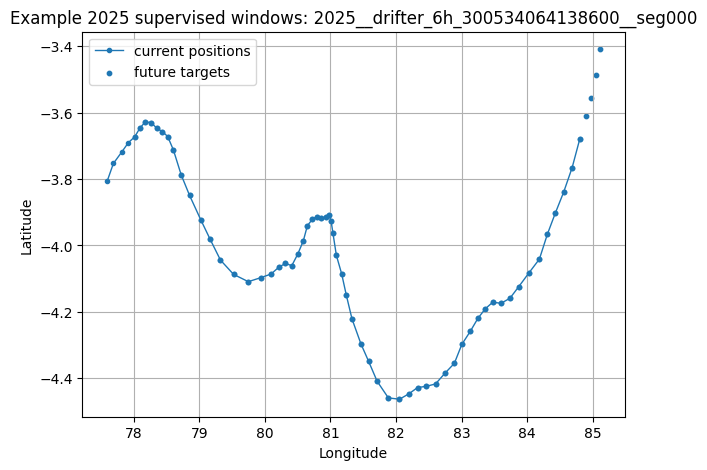

In [15]:
VIS_YEAR = 2025
metadata_path = PROCESSED_DATA_ROOT / f"{VIS_YEAR}_extended" / f"drifter_{VIS_YEAR}_extended_window_metadata.csv"

if metadata_path.exists():
    meta = pd.read_csv(metadata_path)
    display(meta.head())

    # This plot uses current and future positions from the generated supervised windows.
    # It is not the full original trajectory, but it is useful for a quick target-alignment check.
    example_segment = meta["segment_id"].iloc[0]
    seg_meta = meta[meta["segment_id"] == example_segment].copy()

    plt.figure(figsize=(7, 5))
    plt.plot(seg_meta["current_lon"], seg_meta["current_lat"], marker=".", linewidth=1, label="current positions")
    plt.scatter(seg_meta["future_lon"], seg_meta["future_lat"], s=10, label="future targets")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.title(f"Example {VIS_YEAR} supervised windows: {example_segment}")
    plt.grid(True)
    plt.legend()
    plt.show()
else:
    print(f"Metadata not found for {VIS_YEAR}. Run processing first.")
